### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 2
### Due: Monday, Sep. 21 at 11.59pm CST
---

## Problem 1

This question is about Monte Carlo integration. A standard Gaussian integral takes the form 

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

1) Write down the usual form of a Gaussian distribution with $\mu=0$ and $\sigma=\sigma$ that is normalized between $\infty$ and $+\infty$. What is the corresponding form of a half-Gaussian distribution between $0$ and $+\infty$? (Remember that the half-Gaussian distribution must be normalized such that it integrates to one.)

2) Manipulate the above equation such that you can write the left hand side in terms of a normalized half-Gaussian distribution. 

3) Draw $N=10^5$ samples from a $\sigma=3$ normal distribution, mask the samples such that only positive values are accepted, then perform Monte Carlo integration using your equation in (2). Confirm that this *approximately* matches the value computed from the right hand side of the equation. If you don't get approximately matching values then you may have forgotten normalization factors for the Gaussian, or constant factors from translating a normalized Gaussian to a half-Gaussian.

4) Repeat (3) for $N=[10^2,10^3,10^4]$, computing the integral using $100$ different batches of random samples for each $N$. Record all calculated values at all $N$. 

5) Make a plot that shows $\log_{10}N$ along the $x$-axis and the spread between the maximum and minimum Monte Carlo integral values that you get at each $N$ on the $y$-axis. (Note: matplotlib's `fill_between` command is useful for this). Plot a horizontal line on the same figure to show the precise mathematical value. You should see that Monte Carlo integration results in less numerical spread as $N$ gets larger.

In [1]:
import numpy as np
from scipy.stats import norm

### Solution

In [4]:
#part 3
N = 10**5
mu = 0
sigma = 3

np.random.seed(42)
sample = norm(mu, sigma).rvs(N)

mask = sample > 0
sample = sample[mask]

integral = (np.sqrt(2*np.pi)*sigma/2) * np.mean(sample**3)

print("Monte Carlo = %.3f" % integral)
print("Exact = %.3f" % (2*sigma**4))

Monte Carlo = 162.027
Exact = 162.000


In [7]:
#Part 4
Ns = [10**2, 10**3, 10**4]

integrals = []

for N in Ns:
    values = []

    for i in range(100):
        sample = norm(mu, sigma).rvs(N)

        mask = sample > 0
        sample = sample[mask]

        integral = (np.sqrt(2*np.pi)*sigma/2) * np.mean(sample**3)

        values.append(integral)

    integrals.append(values)

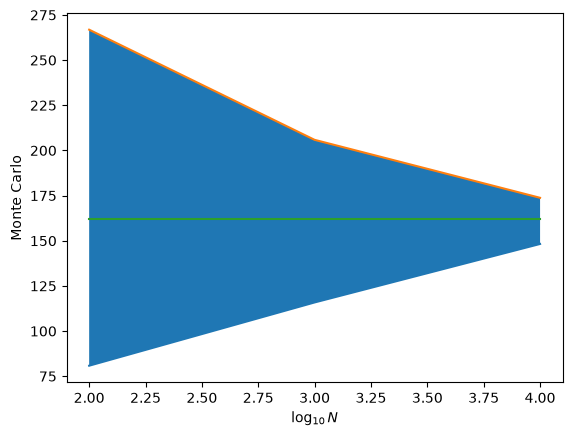

In [10]:
#Part 5
import matplotlib.pyplot as plt

minimum = []
maximum = []

for values in integrals:
    minimum.append(min(values))
    maximum.append(max(values))

x = np.log10(Ns)

plt.fill_between(x, minimum, maximum)
plt.plot(x, minimum)
plt.plot(x, maximum)
plt.plot(x, [2*sigma**4, 2*sigma**4, 2*sigma**4])

plt.xlabel(r'$\log_{10}N$')
plt.ylabel('Monte Carlo')
plt.show()

## Problem 2

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. Access the `ppf` property (percent point function) and use *inverse transform sampling* of the cdf to draw $10^4$ random samples, and make a histogram of these. Overplot the pdf from (1). These should match.

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian object from (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

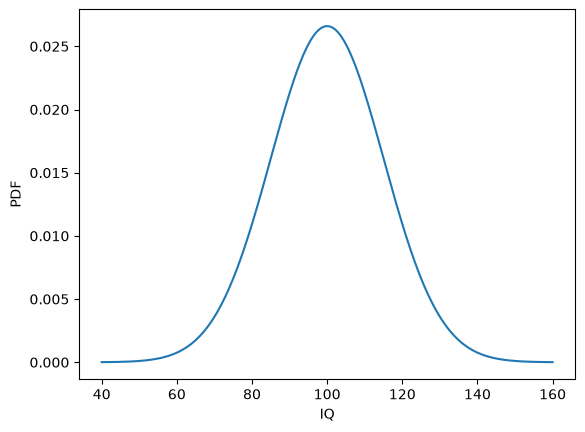

[107.4507123   97.92603548 109.71532807 122.84544785  96.48769938
  96.48794565 123.68819223 111.51152094  92.95788421 108.13840065]
0.0002954565607958672


In [13]:
#Part 1
from scipy.stats import norm

mu = 100
sigma = 15

IQ = norm(mu, sigma)

x = np.linspace(40, 160, 1000)
pdf = IQ.pdf(x)

plt.plot(x, pdf)
plt.xlabel('IQ')
plt.ylabel('PDF')
plt.show()

np.random.seed(42)

sample = IQ.rvs(10)

print(sample)
print(IQ.pdf(145))

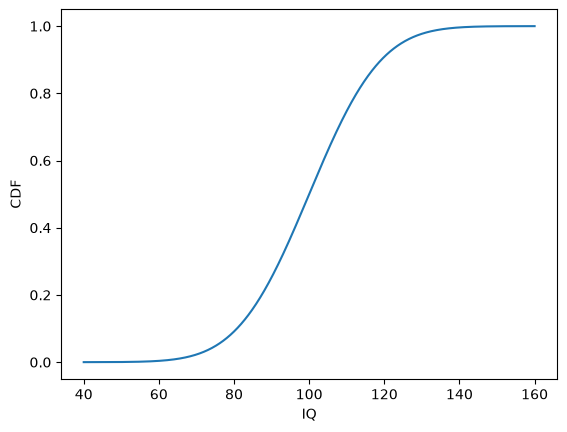

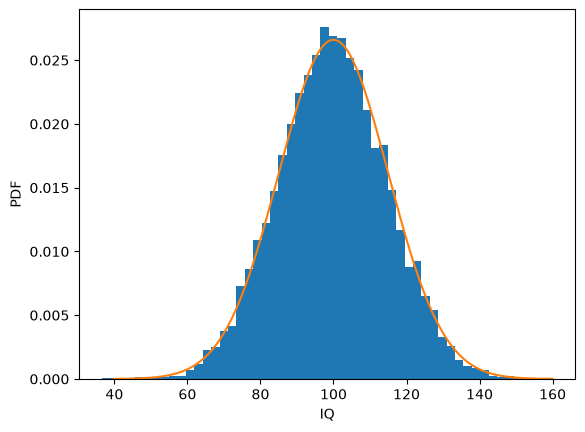

In [15]:
#Part 2
from scipy.stats import uniform

cdf = IQ.cdf(x)

plt.plot(x,cdf)
plt.xlabel('IQ')
plt.ylabel('CDF')
plt.show()

u = uniform.rvs(size=10**4)
sample = IQ.ppf(u)

plt.hist(sample, bins=50, density=True)
plt.plot(x, pdf)
plt.xlabel('IQ')
plt.ylabel('PDF')
plt.show()

In [16]:
#Part 3
fraction = 1 - IQ.cdf(145)
print(fraction)

0.0013498980316301035


In [17]:
#Part 4
IQ_million = IQ.ppf(1 - 10**-6)
print(IQ_million)

171.3013646322563


## Problem 3

This question is about Poisson distributions. A famous early application was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898. Let's take a short look at the kind of data he analyzed.

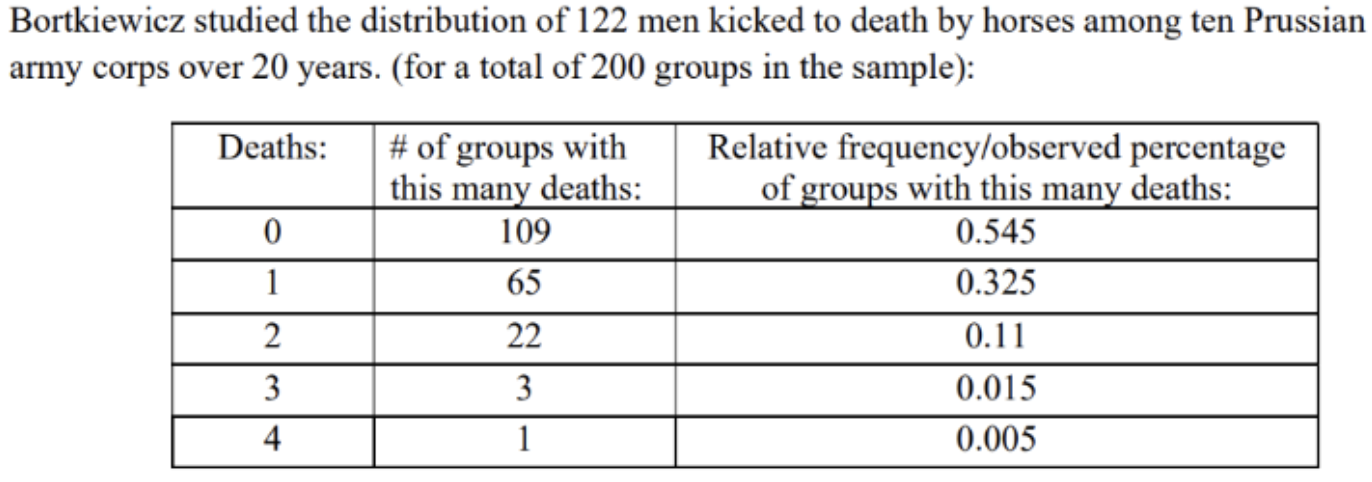

The data essentially consist of 200 total years of Prussian army corps information (i.e. ten army corps over 20 years).

1) Make a plot of the first and third columns of this data.

2) Plot a few Poisson distributions on top that are characterized by different $\mu$ values that might be reasonable guesses for how the data is distributed.

3) We'll come to model fitting next week, but for now use the descriptive sample statistics that you can calculate from this data to deduce the $\mu$ of the modeled Poisson distribution, e.g. the mean, std, median, mode, skewness, and kurtosis, where relevant. Do this however you like, but note that with the data in the table you won't just be able to get a sample mean, since these are tabulated densities, not samples. 

*Hint: use a weighted mean, or alternatively make a dataset that has the numbers 0,1,2,3,4 in agreement with their frequency in the table.*

4) Plot the Poisson distribution with the $\mu$ found in (3) alongside the data.

### Solution

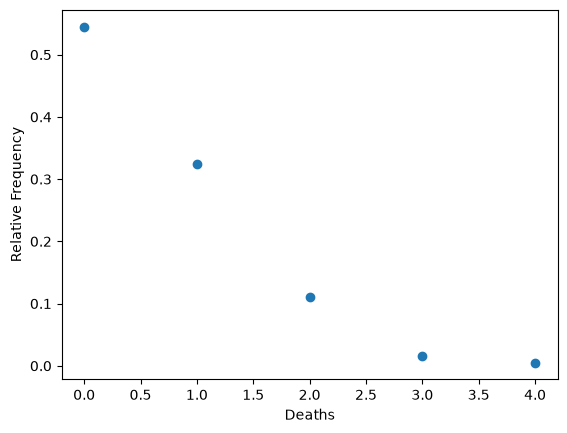

In [19]:
#Part 1
deaths = [0, 1, 2, 3, 4]
frequency = [0.545, 0.325, 0.11, 0.015, 0.005]

plt.plot(deaths, frequency, 'o')
plt.xlabel('Deaths')
plt.ylabel('Relative Frequency')
plt.show()

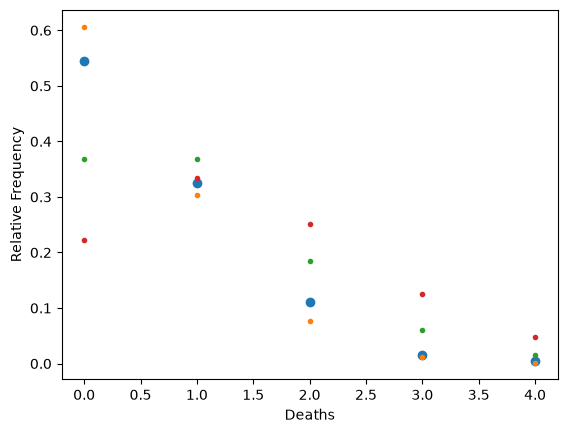

In [21]:
#Part 2
from scipy.stats import poisson

plt.plot(deaths, frequency, 'o')

plt.plot(deaths, poisson.pmf(deaths, 0.5), '.')
plt.plot(deaths, poisson.pmf(deaths, 1.0), '.')
plt.plot(deaths, poisson.pmf(deaths, 1.5), '.')

plt.xlabel('Deaths')
plt.ylabel('Relative Frequency')
plt.show()

In [24]:
#Part 3
groups = [109, 65, 22, 3, 1]

total_deaths = 0
total_groups = 0

for i in range(5):
    total_deaths = total_deaths + deaths[i]*groups[i]
    total_groups = total_groups + groups[i]

mu = total_deaths/total_groups

print(mu)

0.61


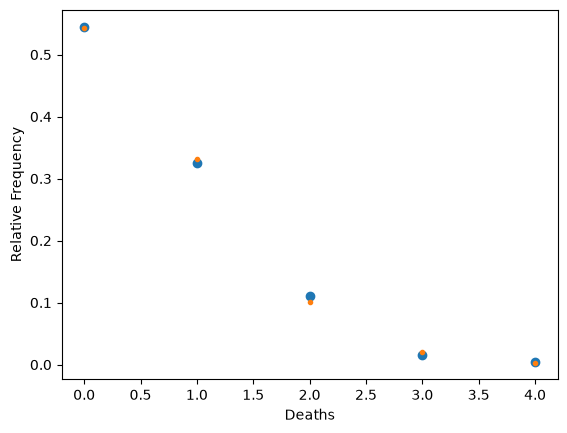

In [26]:
#Part 4
plt.plot(deaths, frequency, 'o')
plt.plot(deaths, poisson.pmf(deaths,mu), '.')

plt.xlabel('Deaths')
plt.ylabel('Relative Frequency')
plt.show()